In [1]:
import os 
os.environ['LANGCHAIN_PROJECT'] = 'HITL'

In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.tools import tool

from dotenv import load_dotenv
import requests



from langgraph.types import interrupt, Command


from dotenv import load_dotenv
from langchain_groq import ChatGroq
import os
load_dotenv()
llm=ChatGroq(
    model="llama-3.1-8b-instant",
    groq_api_key=os.getenv('GROQ_API_KEY'),
    temperature=0
)

# -------------------
# 2. Tools
# -------------------
from langchain_community.tools import DuckDuckGoSearchRun
int_tool = DuckDuckGoSearchRun(description="""Search the web for current information, real-time data, and recent events.

Use this tool ONLY when:
- The user asks about current news, events, or recent developments
- You need real-time information (weather, stock prices, sports scores)
- The user asks about something that happened after your knowledge cutoff
- You genuinely don't know the answer and it requires up-to-date information

DO NOT use this tool for:
- Information the user already provided in this conversation (like their name, preferences)
- General knowledge you already have
- Personal information about the user

Always search with clear, specific queries."""
)





tools = [int_tool]
llm_with_tools = llm.bind_tools(tools)
tool_node = ToolNode(tools)

# -------------------
# 3. State
# -------------------
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]


def chat_node(state: ChatState):
    """LLM node that may answer or request a tool call.
    When you use tools to search for information:
- Trust the tool results and use them to answer the user's question
- Summarize the key points from the search results
- Present the information clearly and concisely
- Don't say you cannot verify the information - the tools provide it for you"""
    messages = state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

def post(state:ChatState):
    """Posts content to a social media platform.
    HUMAN-IN-THE-LOOP:
    Before confirming the purchase, this tool will interrupt
    and wait for a human decision ("yes" / anything else).
    """
    # This pauses the graph and returns control to the caller
    decision = interrupt(f"Do you want to proceed to post ? (yes/no)")
    if isinstance(decision, str) and decision.lower() == "yes":   #if decison is string and yes
        return {
            "messages": ["✅ Response approved and posted"],  # automatically gets converted into HumanMsg
        }
    
    else:
        return {
            "messages": ["❌ Response not posted"],
        }



# -------------------
# 5. Checkpointer (in-memory)
# -------------------
memory = MemorySaver()

# -------------------
# 6. Graph
# -------------------
graph = StateGraph(ChatState)
graph.add_node("chat_node", chat_node)
graph.add_node("tools", tool_node)
graph.add_node("post", post)

graph.add_edge(START, "chat_node")

graph.add_conditional_edges(
    "chat_node",
    tools_condition,  # Use built-in tools_condition
    {
        "tools": "tools",              # When AI wants tools → go to tools node
        "__end__": "post"     # When AI is done → go to HITL (not END!)
    }
)
graph.add_edge("tools", "chat_node")
graph.add_edge("post", END)

chatbot = graph.compile(checkpointer=memory)



c:\Users\Ansh\OneDrive\Desktop\LANGRAPH\meraenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Create a new thread id for this conversation
config = {"configurable": {"thread_id": '15'}}

# ---- STEP 1: user asks a question ----
initial_input = {
    "messages": [HumanMessage(content =  "What is latest news on cricket.")]
}

# Invoke the graph for the first time
result = chatbot.invoke(initial_input, config=config)

In [4]:
result

{'messages': [HumanMessage(content='What is latest news on cricket.', additional_kwargs={}, response_metadata={}, id='779234c4-bd42-4649-9b55-7da9a1a1c445'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'abt0prmz5', 'function': {'arguments': '{"query":"latest cricket news"}', 'name': 'duckduckgo_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 473, 'total_tokens': 492, 'completion_time': 0.025363527, 'completion_tokens_details': None, 'prompt_time': 0.354866085, 'prompt_tokens_details': None, 'queue_time': 0.079132111, 'total_time': 0.380229612}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_6b5c123dd9', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019bcf34-e9dc-7ed3-9222-93ae8301b39c-0', tool_calls=[{'name': 'duckduckgo_search', 'args': {'query': 'latest cricket news'}, 'id': 'abt0prmz5', 'type': 'tool_call'}], usage

In [5]:
msg = result['__interrupt__'][0].value
msg



'Do you want to proceed to post ? (yes/no)'

In [6]:
user_input = input(f"\nBackend message - {msg} \n Approve this question? (y/n): ")


In [7]:
final_result = chatbot.invoke(
                Command(resume=user_input),
                config={"configurable": {"thread_id": "15"}},
            )
print(final_result["messages"])

[HumanMessage(content='What is latest news on cricket.', additional_kwargs={}, response_metadata={}, id='779234c4-bd42-4649-9b55-7da9a1a1c445'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'abt0prmz5', 'function': {'arguments': '{"query":"latest cricket news"}', 'name': 'duckduckgo_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 473, 'total_tokens': 492, 'completion_time': 0.025363527, 'completion_tokens_details': None, 'prompt_time': 0.354866085, 'prompt_tokens_details': None, 'queue_time': 0.079132111, 'total_time': 0.380229612}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_6b5c123dd9', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019bcf34-e9dc-7ed3-9222-93ae8301b39c-0', tool_calls=[{'name': 'duckduckgo_search', 'args': {'query': 'latest cricket news'}, 'id': 'abt0prmz5', 'type': 'tool_call'}], usage_metadata={'inp

In [8]:
from pprint import pprint
pprint(final_result, width=100, depth=None, compact=False)

{'messages': [HumanMessage(content='What is latest news on cricket.', additional_kwargs={}, response_metadata={}, id='779234c4-bd42-4649-9b55-7da9a1a1c445'),
              AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'abt0prmz5', 'function': {'arguments': '{"query":"latest cricket news"}', 'name': 'duckduckgo_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 473, 'total_tokens': 492, 'completion_time': 0.025363527, 'completion_tokens_details': None, 'prompt_time': 0.354866085, 'prompt_tokens_details': None, 'queue_time': 0.079132111, 'total_time': 0.380229612}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_6b5c123dd9', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019bcf34-e9dc-7ed3-9222-93ae8301b39c-0', tool_calls=[{'name': 'duckduckgo_search', 'args': {'query': 'latest cricket news'}, 'id': 'abt0prmz5', 'type': 'tool_ca

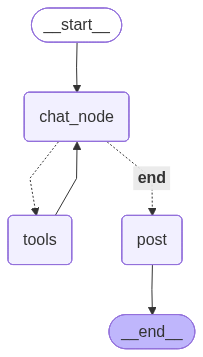

In [9]:
graph.compile(checkpointer=memory)